12:10:48 - cmdstanpy - INFO - Chain [1] start processing
12:10:48 - cmdstanpy - INFO - Chain [1] done processing


Prophet MAE: 3618.80


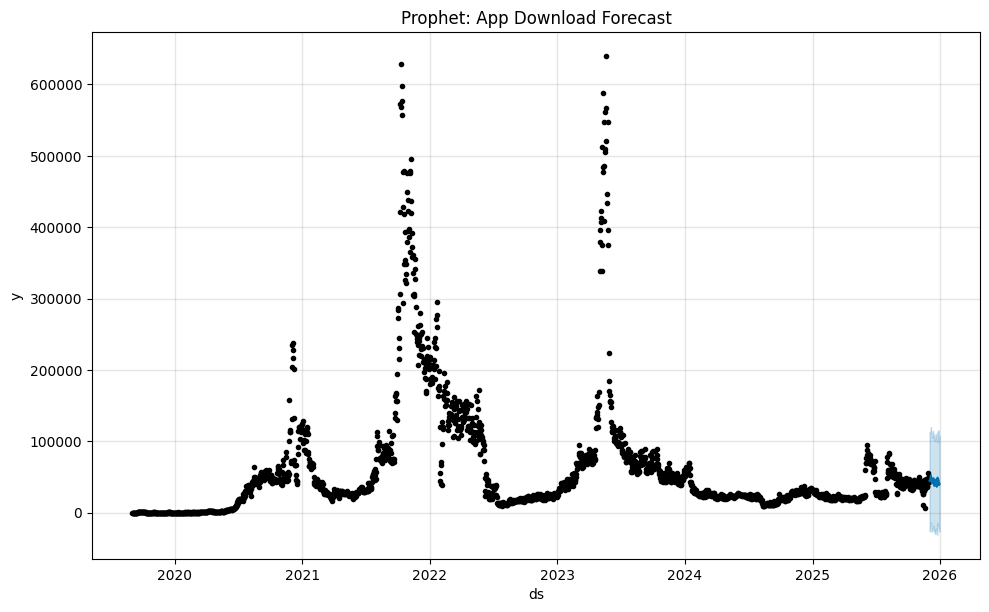

In [21]:
import pandas as pd
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# 1. Load Cleaned Data
df = pd.read_csv('../../../data/ds_data_clean.csv')
df['Date'] = pd.to_datetime(df['Date'])

# 2. Prepare Data for Prophet (Rename columns to 'ds' and 'y')
# We'll also keep 'Daily Average Rating' and 'Daily Crashes' as regressors
prophet_df = df[['Date', 'Daily User Installs', 'Daily Average Rating', 'Daily Crashes']].copy()
prophet_df.columns = ['ds', 'y', 'rating', 'crashes']

# 3. Train/Test Split (Last 30 days for testing)
train = prophet_df.iloc[:-30]
test = prophet_df.iloc[-30:]

# 4. Initialize and Fit Model
model = Prophet(yearly_seasonality=True, weekly_seasonality=True)
model.add_country_holidays(country_name='US') # Useful for App Store trends

# Add additional regressors
model.add_regressor('rating')
model.add_regressor('crashes')

model.fit(train)

# 5. Create Future Dataframe for prediction
# We must include the regressor values (rating/crashes) for the test period
future = test[['ds', 'rating', 'crashes']].copy()
forecast = model.predict(future)

# 6. Evaluation
mae = mean_absolute_error(test['y'], forecast['yhat'])
print(f"Prophet MAE: {mae:.2f}")

# Plotting
model.plot(forecast)
plt.title("Prophet: App Download Forecast")
plt.savefig('prophet_forecast_plot.png')